# 步骤1：导入该实验所需的通用包
FROM 《第9章 人工智能辅助的化学计量学实验-教材》（实验9-2  拉曼光谱的表示与预处理）  
使用到的通用包有：***NumPy***、***Matplotlib*** 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimSun'] # 用来正常显示中文标签


# 步骤2：导入原始数据，对其进行向量表示

### 2.1 导入原始数据
原始数据的存储格式为.csv文件，第一列指的是拉曼位移，每二列指的是拉曼强度。  

            



In [3]:
import pandas as pd
path='WS-23-1-0.csv'  #原始数据存储格式为.csv文件
data = pd.read_csv(path, delimiter='\t', header=None)  #读取数据
print(data)


             0        1
0      200.052  81.8966
1      201.312  79.2069
2      202.571  85.7586
3      203.830  84.8621
4      205.088  83.6897
...        ...      ...
1525  1796.000  67.7586
1526  1796.880  68.6552
1527  1797.750  68.8621
1528  1798.620  70.5862
1529  1799.490  68.2414

[1530 rows x 2 columns]


## 2.2 拉曼光谱数据的向量表示及可视化
首先将数据转换为array数组形式，再分别取出以向量的形式表示的拉曼位移数据（光谱图的横轴）和其对应的拉曼强度数据（光谱图的纵轴）。

In [4]:
data_array=np.array(data.T) #将数据转换为数组
print(data_array)
x=data_array[0] #x轴数据表示拉曼位移，可表示成向量数据
print(x)
print(x.shape)
y=data_array[1] #y轴数据表示拉曼强度，可表示成向量数据
print(y)
print(y.shape)

[[ 200.052   201.312   202.571  ... 1797.75   1798.62   1799.49  ]
 [  81.8966   79.2069   85.7586 ...   68.8621   70.5862   68.2414]]
[ 200.052  201.312  202.571 ... 1797.75  1798.62  1799.49 ]
(1530,)
[81.8966 79.2069 85.7586 ... 68.8621 70.5862 68.2414]
(1530,)


## 2.3 根据x轴和y轴数据，绘制原始拉曼光谱图。

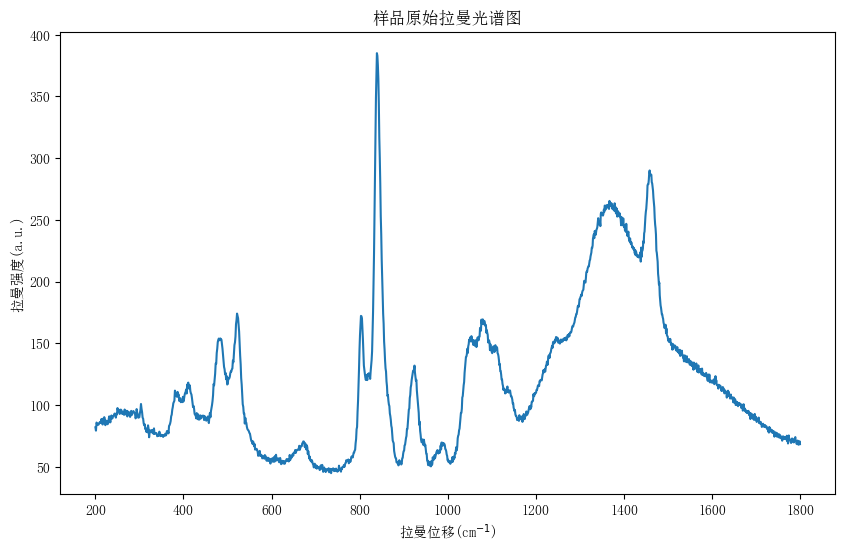

In [8]:
plt.figure(figsize=(10,6))
plt.plot(x,y)
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('样品原始拉曼光谱图')
plt.show()

#### 从那格列奈样品原始拉曼光谱图可看出存在噪声、基线漂移，需要进行平滑去噪、基线校正。

# 步骤3：平滑去噪
### 3.1 窗口移动平均法


原始拉曼光谱数据: [81.8966 79.2069 85.7586 ... 68.8621 70.5862 68.2414]
移动平均结果: [40.9483  80.55175 82.48275 ... 68.75865 69.72415 69.4138 ]


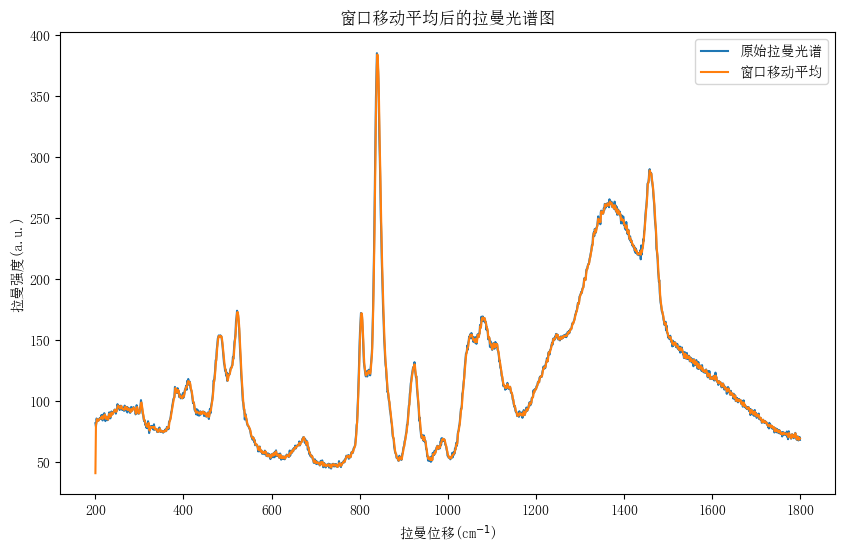

In [9]:
from scipy.signal import convolve
# 定义窗口大小
window_size = 2

# 创建一个窗口数组，这里使用窗口大小为window_size的全1数组
window = np.ones(window_size) / window_size

# 使用convolve函数计算移动平均
moving_average_y = convolve(y, window, mode='same')

print("原始拉曼光谱数据:", y)
print("移动平均结果:", moving_average_y)
plt.figure(figsize=(10,6))
plt.plot(x,y, label='原始拉曼光谱')
plt.plot(x,moving_average_y, label='窗口移动平均')
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('窗口移动平均后的拉曼光谱图')
plt.legend()
plt.show()


### 3.2 窗口移动多项式法（Savitzky–Golay filter）

原始拉曼光谱数据: [81.8966 79.2069 85.7586 ... 68.8621 70.5862 68.2414]
窗口移动多项式平滑后的数据: [81.55571571 80.57043714 83.71329429 ... 69.53007143 70.14088571
 68.35272857]


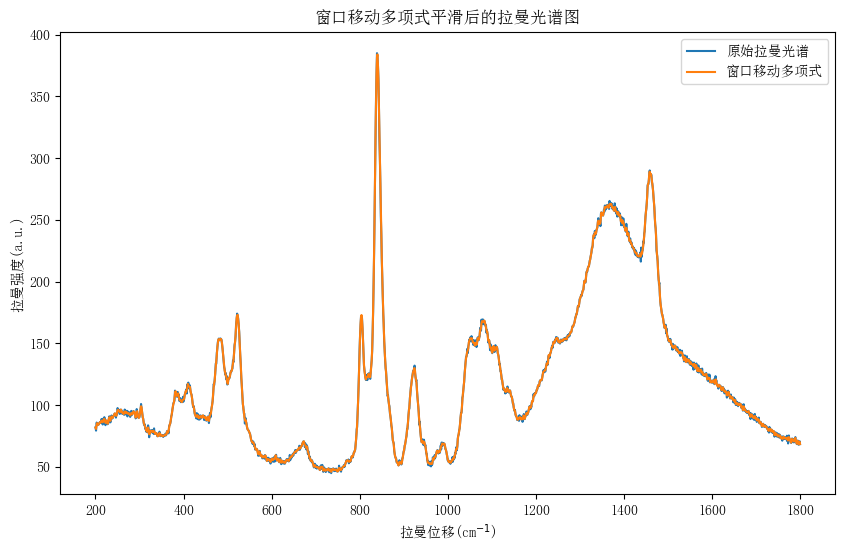

In [7]:
from scipy.signal import savgol_filter
# 定义窗口大小（必须是奇数）
window_size = 5

# 定义多项式的阶数
polyorder = 3

# 使用savgol_filter函数计算窗口移动多项式平滑
sg_smoothed_y = savgol_filter(y, window_length=window_size, polyorder=polyorder)
print("原始拉曼光谱数据:", y)
print("窗口移动多项式平滑后的数据:", sg_smoothed_y)
plt.figure(figsize=(10,6))
plt.plot(x,y, label='原始拉曼光谱')
plt.plot(x,sg_smoothed_y, label='窗口移动多项式')
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('窗口移动多项式平滑后的拉曼光谱图')
plt.legend()
plt.show()

### 3.3 惩罚最小二乘法（维特克平滑法）
下面代码来源于[whittaker_smooth](https://github.com/mhvwerts/whittaker-eilers-smoother/blob/master/whittaker_smooth.py)。 此处为了方便使用，代码直接单元格形式，实际代码应单独写入至"whittaker_smooth.py"文件中。

In [11]:
import numpy as np
import scipy.sparse as sparse
from scipy.sparse.linalg import splu


def speyediff(N, d, format='csc'):
    """
    (utility function)
    Construct a d-th order sparse difference matrix based on 
    an initial N x N identity matrix
    
    Final matrix (N-d) x N
    """
    
    assert not (d < 0), "d must be non negative"
    shape     = (N-d, N)
    diagonals = np.zeros(2*d + 1)
    diagonals[d] = 1.
    for i in range(d):
        diff = diagonals[:-1] - diagonals[1:]
        diagonals = diff
    offsets = np.arange(d+1)
    spmat = sparse.diags(diagonals, offsets, shape, format=format)
    return spmat


def whittaker_smooth(y, lmbd, d = 2):
    """
    Implementation of the Whittaker smoothing algorithm,
    based on the work by Eilers [1].

    [1] P. H. C. Eilers, "A perfect smoother", Anal. Chem. 2003, (75), 3631-3636
    
    The larger 'lmbd', the smoother the data.
    For smoothing of a complete data series, sampled at equal intervals

    This implementation uses sparse matrices enabling high-speed processing
    of large input vectors
    
    ---------
    
    Arguments :
    
    y       : vector containing raw data
    lmbd    : parameter for the smoothing algorithm (roughness penalty)
    d       : order of the smoothing 
    
    ---------

    Returns :
    
    z       : vector of the smoothed data.
    """

    m = len(y)
    E = sparse.eye(m, format='csc')
    D = speyediff(m, d, format='csc')
    coefmat = E + lmbd * D.conj().T.dot(D)
    z = splu(coefmat).solve(y)
    return z    

原始拉曼光谱数据: [81.8966 79.2069 85.7586 ... 68.8621 70.5862 68.2414]
惩罚最小二乘平滑后的数据: [82.03283949 82.10095923 83.61610859 ... 69.10600766 69.35249509
 68.98213006]


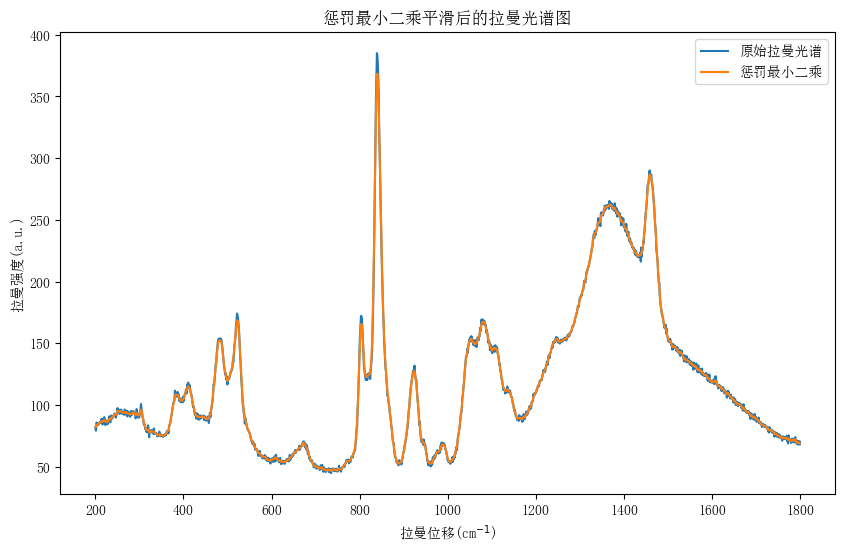

In [12]:
# from Whittaker_smoother import whittaker_smooth  # 从文件夹中的Whittaker_smoother.py文件导入自定义的Whittaker_smooth函数
whittaker_smooth_y = whittaker_smooth(y, lmbd=2, d=1) #lmbd代表惩罚项的系数，d代表差分的阶数，二者用于控制平滑的程度
print("原始拉曼光谱数据:", y)
print("惩罚最小二乘平滑后的数据:", whittaker_smooth_y)
plt.figure(figsize=(10,6))
plt.plot(x,y, label='原始拉曼光谱')
plt.plot(x,whittaker_smooth_y, label='惩罚最小二乘')
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('惩罚最小二乘平滑后的拉曼光谱图')
plt.legend()
plt.show()


**从三种方法的平滑结果图中来看，窗口移动多项式平滑对于该光谱的平滑效果最好。下面，我们基于窗口移动多项式平滑后的数据（sg_smoothed_y）进行基线校正。**


# 步骤4：基线校正
从pybaselines库导入Baselines模块，Baselines模块提供了多种基线校正算法，包含本实验涉及到的改进的修正多项式法（I-ModPoly）、自适应重加权惩罚最小二乘法（airPLS）、形态学加权惩罚最小二乘法（MPLS）这三种基线校正方法，运行这三种基线校正方法并在同一张图上可视化比较基线拟合效果。

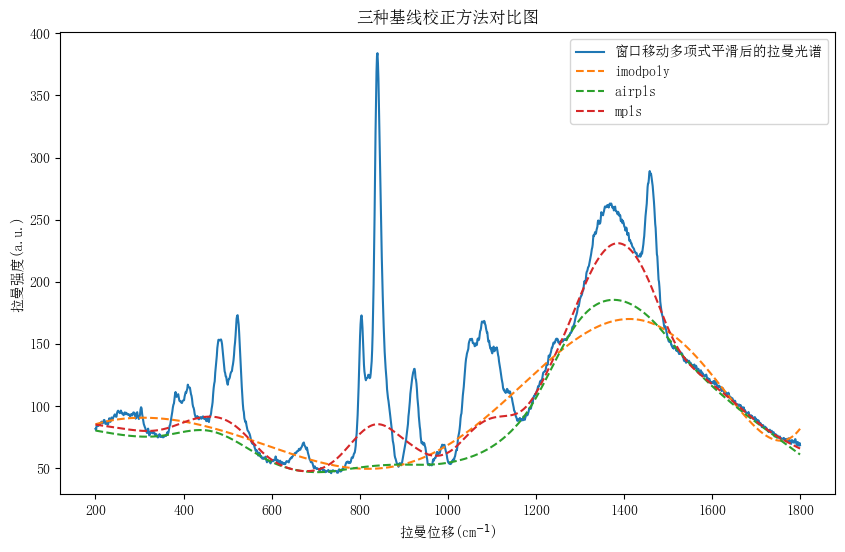

In [9]:
from pybaselines import Baseline
baseline_fitter = Baseline(x_data=x)
bkg_1, params_1 = baseline_fitter.imodpoly(sg_smoothed_y, poly_order=7) #改进的修正多项式法
imodpoly_y = sg_smoothed_y - bkg_1
bkg_2, params_2 = baseline_fitter.airpls(sg_smoothed_y, lam=1e5) #自适应加权惩罚最小二乘法
airpls_y = sg_smoothed_y - bkg_2
bkg_3, params_3 = baseline_fitter.mpls(sg_smoothed_y, lam=1e5, p=0.01) #形态学加权惩罚最小二乘法
mpls_y = sg_smoothed_y - bkg_3
plt.figure(figsize=(10,6))
plt.plot(x, sg_smoothed_y, label='窗口移动多项式平滑后的拉曼光谱')
plt.plot(x, bkg_1, '--', label='imodpoly')
plt.plot(x, bkg_2, '--', label='airpls')
plt.plot(x, bkg_3, '--', label='mpls')
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('三种基线校正方法对比图')
plt.legend()
plt.show()

### 4.2 可视化经改进的修正多项式法基线校正后的拉曼光谱

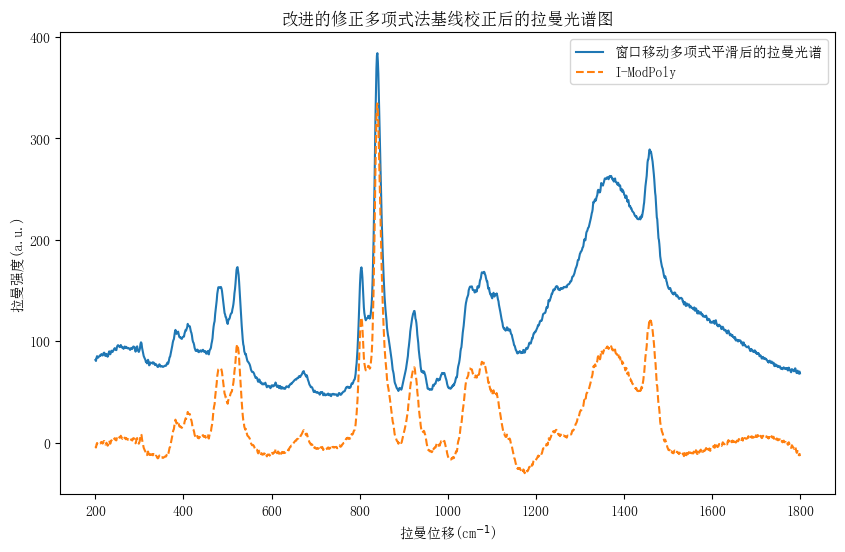

In [16]:
plt.figure(figsize=(10,6))
plt.plot(x, sg_smoothed_y, label='窗口移动多项式平滑后的拉曼光谱')
plt.plot(x,imodpoly_y , '--', label='I-ModPoly')
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('改进的修正多项式法基线校正后的拉曼光谱图')
plt.legend()
plt.show()

### 4.3 可视化经自适应重加权惩罚最小二乘法基线校正后的拉曼光谱

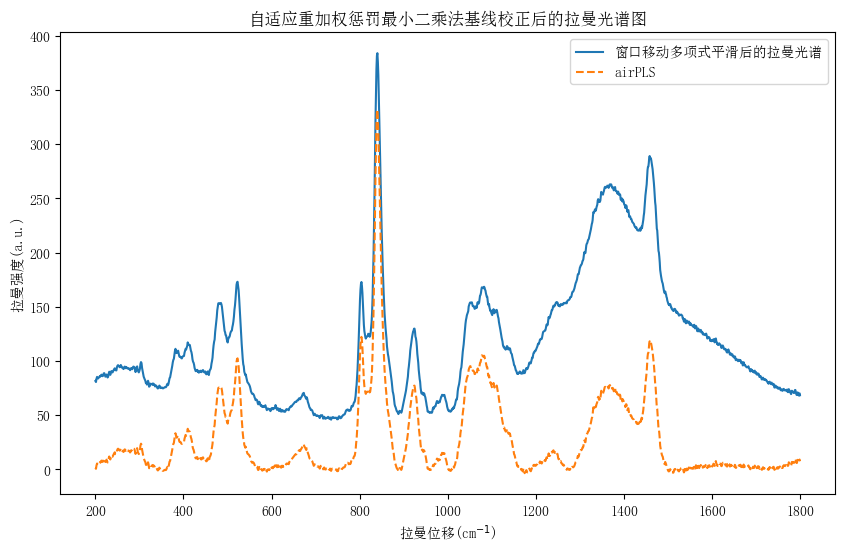

In [17]:
plt.figure(figsize=(10,6))
plt.plot(x, sg_smoothed_y, label='窗口移动多项式平滑后的拉曼光谱')
plt.plot(x,airpls_y , '--', label='airPLS')
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('自适应重加权惩罚最小二乘法基线校正后的拉曼光谱图')
plt.legend()
plt.show()

### 4.4 可视化经形态学加权惩罚最小二乘法基线校正后的拉曼光谱

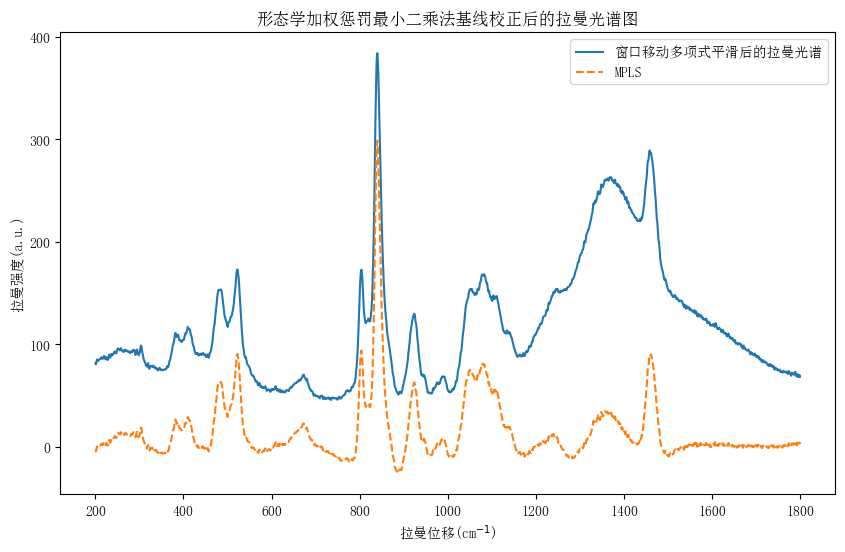

In [18]:
plt.figure(figsize=(10,6))
plt.plot(x, sg_smoothed_y, label='窗口移动多项式平滑后的拉曼光谱')
plt.plot(x,mpls_y, '--', label='MPLS')
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('形态学加权惩罚最小二乘法基线校正后的拉曼光谱图')
plt.legend()
plt.show()

**从上述三种方法的基线校正效果图可看出，自适应重加权惩罚最小二乘法取得了最好的效果。下面基于自适应重加权惩罚最小二乘法基线校正后的光谱数据（airpls_y）进行峰检测。**

# 步骤5： 峰检测

### 5.1 基于峰性质的检测方法（SciPy库中的find_peaks函数）

检测到的峰位置索引: [  46   69   83   96  147  170  233  265  339  395  512  545  623  682
  743  769  795  931 1036 1063 1075 1156 1232 1267 1292 1316 1333 1347
 1385 1413 1500 1517]
峰的性质: {'peak_heights': array([ 19.48370456,  19.10989556,  23.64843341,   6.49626217,
        33.3050364 ,  37.42267759,  76.29207664, 102.41207714,
         5.86638288,  23.18547897, 122.23876552, 332.09429975,
        77.23201999,  15.20041636,  95.10870938, 105.22507345,
        79.68886524,  17.52929083,  66.93791248,  77.72967663,
        75.12235244, 118.15139184,   1.14601696,   3.68751301,
         4.77077266,   7.58649326,   6.05324437,   6.28703837,
         4.38962702,   3.43124588,   6.48316813,   9.62732034]), 'prominences': array([  5.28504562,   3.53597691,  23.16238954,   3.52220317,
         9.85150169,  30.42372035,  34.12401055, 103.82825184,
         4.40596292,  24.86772955,  52.62219145, 334.20797223,
        78.70748217,  15.83021335,   7.17382774, 106.98543102,
         4.7451735 ,  18.0952

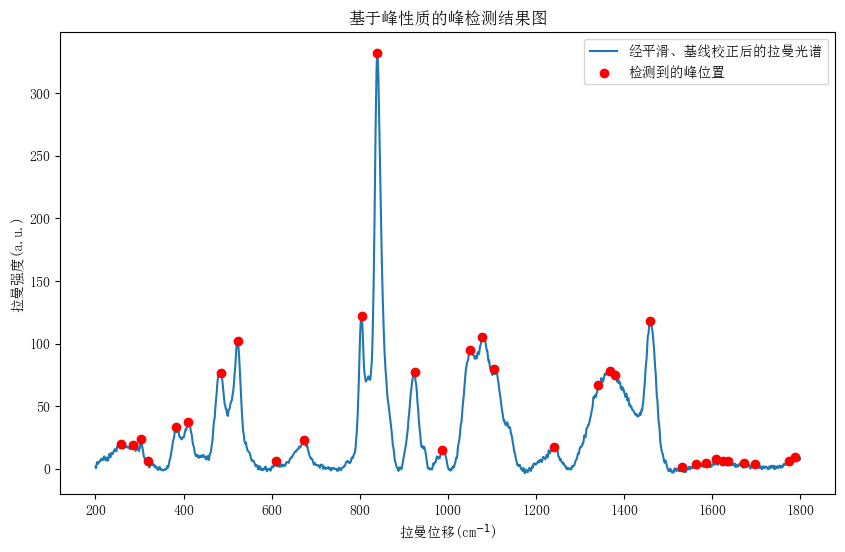

In [16]:
from scipy.signal import find_peaks
peaks,properties = find_peaks(airpls_y,height=0,distance=10,width=2, prominence=3, rel_height=0.5)
print("检测到的峰位置索引:", peaks)
print("峰的性质:", properties)
plt.figure(figsize=(10,6))
plt.plot(x,airpls_y, label='经平滑、基线校正后的拉曼光谱')
plt.scatter(x[peaks], airpls_y[peaks], color='red', zorder=5, label='检测到的峰位置')
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('基于峰性质的峰检测结果图')
plt.legend()
plt.show()

### 5.2 连续小波变换方法(MassSpecWavelet)

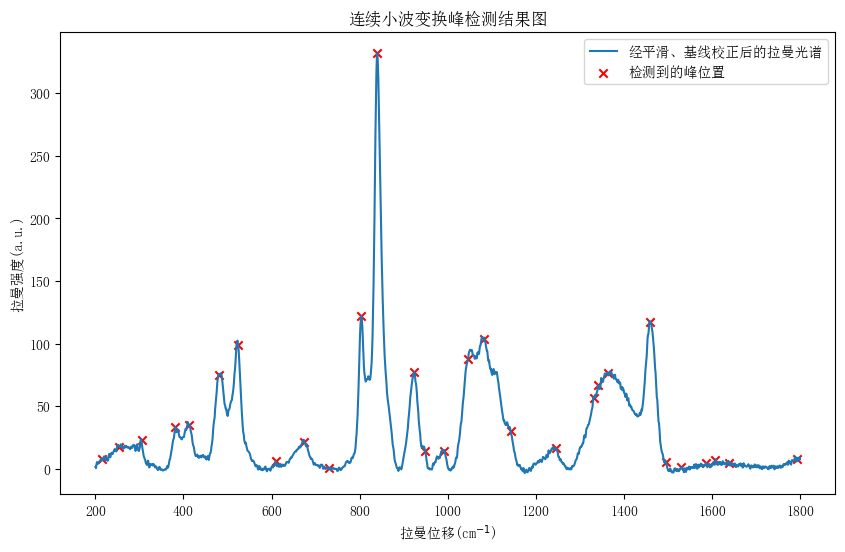

In [26]:
from scipy.signal import find_peaks_cwt
widths=np.arange(1,15)#widths表示尺度，是一个连续变化的参数
min_snr=1.9 #min_snr表示信噪比
peak_ind = find_peaks_cwt(airpls_y,widths,min_snr=min_snr)#默认为Ricker波形
# 绘制峰检测结果图
plt.figure(figsize=(10,6))
plt.plot(x,airpls_y, label='经平滑、基线校正后的拉曼光谱')
plt.scatter(x[peak_ind],airpls_y[peak_ind],c='r', marker='x', label='检测到的峰位置')
plt.legend()
plt.xlabel('拉曼位移(cm$^{-1}$)')
plt.ylabel('拉曼强度(a.u.)')
plt.title('连续小波变换峰检测结果图')
plt.show()

**比较这二种方法的峰检测结果图，可看出对于该条拉曼光谱用SciPy中的find_peaks()方法检测峰值效果最好。**